# SV LAB: MedViz warmup

Group members: Sergi Bons, Ignasi Granell, Carles Matoses



# 1. Introduction to SimpleITK
Overview, installation, and its role in medical visualization.

## Installation

The python package can be installed using pip.

It can also be built from source https://simpleitk.readthedocs.io/en/master/building.html#building-simpleitk

In [ ]:
!pip install simpleitk

In [ ]:
# Download required files
!wget https://raw.githubusercontent.com/carlesmatoses/SV/master/proj2/imgs/low_low_resolution.nii.gz
!wget https://raw.githubusercontent.com/carlesmatoses/SV/master/proj2/myshow.py
!wget https://raw.githubusercontent.com/carlesmatoses/SV/master/proj2/imgs/DICOM.zip


## Overview

```
Pau Adell Raventós

Brief, explains the purpose and general functionaing of the library very clearly!
```

ITK refers to the Insight toolkit, designed to make advanced image analysis and other operations such as segmentation.

SimpleITK provides different interfaces for a variety of languages such as python.

## Role in medical visualization

ITK works as an abstraction layer in medical image analysis simplifying operations. Multiple medical image analysis applications and libraries incorporate SimpleITK as a key building block.

Some of the main functions it provides are:
- Filters: like gaussian blur, resampling...
- Segmentation & registration: Offers a robust framework for aligning images and identifying specific structures within them.
- Simplified API: Provides a simplified interface to the more complex ITK library, hiding the details of its templated C++ interface.

# 2. Loading and Displaying Images

Load and visualize a 2D or 3D medical dataset (SimpleITK sample data or a small open dataset).
Display slices or overlays.

In [ ]:
import SimpleITK as sitk
%matplotlib inline
import matplotlib.pyplot as plt

# we create images with
image = sitk.Image(256, 128, 64, sitk.sitkInt16)
img = sitk.GaussianSource(size=[128] * 2)
image_2D = sitk.Image(64, 64, sitk.sitkFloat32)
image_2D = sitk.Image([32, 32], sitk.sitkUInt32)
image_RGB = sitk.Image([128, 128], sitk.sitkVectorUInt8, 3)

# We visualize image properties by accessing the class
print(f"Image dimension: {image.GetDimension()}")
print(f"Image size: {image.GetSize()}")
print(f"Image origin: {image.GetOrigin()}")
print(f"Image spacing: {image.GetSpacing()}")

# to plot the image we use matplotlib
z = 0
slice = sitk.GetArrayViewFromImage(image)[z, :, :]
plt.imshow(slice)
plt.show()

# if image is already 2D we can plot it with
plt.imshow(sitk.GetArrayViewFromImage(img))
plt.show()


We can load files as images using matplotlib:

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import SimpleITK as sitk

!wget -O img.jpg https://carlesmatoses.github.io/images/ambient_occlusion/ambient%20occlusion%20example.png

# load image (using matplotlib)
img = plt.imread('img.jpg')

# turn it into a numpy array
np_array = np.array(img)

# turn it into a SimpleITK image
sitk_image = sitk.GetImageFromArray(np_array)

# show it in matplotlib
plt.imshow(sitk.GetArrayViewFromImage(sitk_image))


Additionally we can use SITK to load more complex images such as 3D images:

In [ ]:

image = sitk.ReadImage("low_low_resolution.nii.gz", imageIO="NiftiImageIO")

slice = image[:,100,:]

plt.imshow(sitk.GetArrayViewFromImage(slice)); plt.show()


# 3. Basic Image Manipulation

Show resizing, resampling, cropping, and intensity transformation.

## Slicing and cropping

Slicing a 3D image can be done like normal python arrays

In [ ]:
import SimpleITK as sitk
import matplotlib.pyplot as plt

image = sitk.ReadImage("low_low_resolution.nii.gz", imageIO="NiftiImageIO")

slice_1 = image[:,:,25]
slice_2 = image[:,100,:]

plt.imshow(sitk.GetArrayViewFromImage(slice_1)); plt.show()
plt.imshow(sitk.GetArrayViewFromImage(slice_2))

Cropping can be similarly achieved with slices.

In [ ]:
cropped_slice = slice_2[:, :64]
plt.imshow(sitk.GetArrayViewFromImage(cropped_slice))


```
Pau Adell Raventós

It is true that you can crop only getting the needed slices, but that has its limitations! There is a sitk functionality named RegionOfInterest()
```

RegionOfInterest() can be used for selecting a subregion of the image and create a copy of it.


In [ ]:
cropped_slice2 = sitk.RegionOfInterest( image1=slice_2,
                       size=[64, slice_2.GetSize()[1]], # we want 64 columns
                       index=[0,0]) # we start at the first column
plt.imshow(sitk.GetArrayViewFromImage(cropped_slice2));plt.show()

## Resampling

Resampling can be achieved with the resample function, it takes an image, a resampling grid, a transformation and an interpolator

In [ ]:
spacing = image.GetSpacing()
size = image.GetSize()
output_size = [
    int(size[0]/2),
    int(size[1]/2),
    int(size[2]/2)
]
output_spacing = [int(spacing[0]*2), int(spacing[1]*2), int(spacing[2]*2)]

image_lower = sitk.Resample(
    image,
    output_size,
    sitk.Transform(3, sitk.sitkIdentity),
    sitk.sitkLinear,
    image.GetOrigin(),
    output_spacing,
    image.GetDirection()
)

slice_3 = image_lower[:,:,12]
plt.imshow(sitk.GetArrayViewFromImage(slice_3))

Transformations can be applied with resampling

In [ ]:
translation = sitk.TranslationTransform(3) # 3 Dimension translate
translation.SetParameters((20, -10, 30))

translated = sitk.Resample(image, image, translation, sitk.sitkLinear)
slice_4 = translated[:,:,25]
plt.imshow(sitk.GetArrayViewFromImage(slice_4))

# 4. Image Registration

Implement a basic registration example (e.g., rigid or translation). Visualize before / after
alignment.

In [ ]:
import SimpleITK as sitk
import matplotlib.pyplot as plt

# Helper function to display images
def show_image(image, title=None):
    plt.imshow(sitk.GetArrayViewFromImage(image), cmap='gray')
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()


#We add a 2D transform and then remap for clarity:
translation = sitk.TranslationTransform(3)
translation.SetParameters((20, -10, 0))

translated = sitk.Resample(image, image, translation, sitk.sitkLinear)
moved_image = translated[:,:,25]
ref_image = image[:,:,25]

# Cast images to float32 for registration
ref_image = sitk.Cast(ref_image, sitk.sitkFloat32)
moved_image = sitk.Cast(moved_image, sitk.sitkFloat32)

# Show the fixed and moving images
show_image(ref_image, "Fixed Image")
show_image(moved_image, "Moving Image (Transformed)")

# 3. Initialize the registration
registration_method = sitk.ImageRegistrationMethod()

# We need to set metric to perform image registration
registration_method.SetMetricAsMeanSquares()

# We also need to set an optimizer, gradient descent will do
registration_method.SetOptimizerAsRegularStepGradientDescent(
    learningRate=2.0,
    minStep=1e-4,
    numberOfIterations=200,
    gradientMagnitudeTolerance=1e-8
)

# We set an Interpolator
registration_method.SetInterpolator(sitk.sitkLinear)

# We set the tranforms type: rigid (translation + rotation)
initial_transform = sitk.CenteredTransformInitializer(
    ref_image, moved_image, sitk.Euler2DTransform(),
    sitk.CenteredTransformInitializerFilter.GEOMETRY
)

registration_method.SetInitialTransform(initial_transform, inPlace=False)

# Run the registration
final_transform = registration_method.Execute(ref_image, moved_image)

# Apply the resulting transform
registered_image = sitk.Resample(moved_image, ref_image, final_transform, sitk.sitkLinear, 0.0, moved_image.GetPixelID())

# Display the resulting image
show_image(registered_image, "Registered Image")


#Here are some of the metrics
#print("Final Transform Parameters:")
#print(final_transform)

# Compute and print the metric value
# print("Final metric value: ", registration_method.GetMetricValue())

# 5. Visualization Enhancement
## Context
Apply and compare visualization methods (color maps, overlays, annotations, segmentation masks, or 3D rendering). Explain your choices and what they reveal about the data.

We have two different images:

### NIfTI Format (`.nii.gz`)
- **File**: `imgs/low_low_resolution.nii.gz`
- **Nature**: NIfTI (Neuroimaging Informatics Technology Initiative) is a standard format for neuroimaging data, though widely used for other medical imaging modalities
- **Structure**: Contains a 3D volumetric image with metadata including:
  - Spatial dimensions (voxel spacing, orientation)
  - Data type (int16, float32, etc.)
  - Affine transformation matrix (maps voxel coordinates to real-world coordinates)
- **Compression**: The `.gz` extension indicates gzip compression to reduce file size
- **Use cases**: MRI, CT scans, PET scans - primarily research and clinical analysis
- **Advantages**: Single file contains both image data and metadata; standardized coordinate system

### DICOM Format (`DICOMDIR`)
- **File**: `imgs/DICOMDIR`
- **Nature**: DICOM (Digital Imaging and Communications in Medicine) is the international standard for medical imaging
- **Structure**:
  - `DICOMDIR` is an index/catalog file that references multiple DICOM files (typically one file per slice)
  - Each DICOM file contains a single 2D slice plus extensive metadata (patient info, acquisition parameters, equipment details)
  - The `DICOM/` folder contains numbered files (I0, I1, ..., I302) representing individual slices
- **Metadata richness**: Contains comprehensive information:
  - Patient demographics
  - Study/series information
  - Acquisition parameters (slice thickness, pixel spacing, modality)
  - Equipment manufacturer and settings
- **Use cases**: Clinical workflow standard - used in hospitals, PACS systems, and medical devices
- **Advantages**: Industry standard; preserves all clinical metadata; supports various modalities (CT, MRI, X-ray, ultrasound, etc.)

In [ ]:
# Libraries used in this section
import SimpleITK as sitk
import numpy as np
from ipywidgets import interact, fixed
from IPython.display import display, clear_output
from myshow import myshow, myshow3d
import matplotlib.pyplot as plt
%matplotlib inline

# We are given a 3D image so rendering it in 3D is more appropriate
image = sitk.ReadImage("low_low_resolution.nii.gz", imageIO="NiftiImageIO")

## Color Maps

Matplotlib offers a large set of maps: plt.colormaps()

I decided to use some of them that will be relevant for the rest of the section

---

Some maps such as "jet" are usefull for representing big changes, maybe lessions could be more visible there. Plasma or heat can show differences on a more perceived linearity.

```
Pau Adell Raventós

Best example of comparison between colormaps with the additional slicing option!
```


In [ ]:
# Compare different colormaps on the same slice

# I think i have to create the figure first
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
cmaps = ['gray', 'viridis', 'hot', 'jet', 'bone', 'plasma']
plt.colormaps()

# Now i can create the images inside the fig
ims = []
for idx, cmap in enumerate(cmaps):
    ax = axes[idx // 3, idx % 3]
    im = ax.imshow(np.zeros((10,10)), cmap=cmap)  # placeholder
    ax.set_title(f'Colormap: {cmap}', fontsize=12)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)
    ims.append(im)

# tight makes the layout better
plt.tight_layout()
plt.close(fig)  # we will display it later

execution_count = 0

# do this each time we want to change the slice
def custom_plot(z):
    global execution_count
    execution_count += 1
    print(f"Execution count: {execution_count}")
    # We now update the images inside the fig
    slice = image[z,:,:]
    slice_array = sitk.GetArrayViewFromImage(slice)

    for im in ims:
        im.set_data(slice_array)
        im.set_clim(vmin=slice_array.min(), vmax=slice_array.max())

    # Refresh display (only updates changed pixels)
    # clear_output(wait=True)

    # What is the difference between plt.show() and display()?
    # plt.show()  # this would create a new figure each time
    display(fig) # this updates the existing figure

z = 100;
interact(lambda z: custom_plot(z), z=(0, 120));

## Canny Edge Detection

Canny offers edge detection and segmentation based on this edges. Lets see if we can isolate the bones.

I will be using this images for other sections.

---

What i want to ilustrate here is that the domain in which we apply a filter will have a strong inpact. In this case, applying the Canny edge detection only on a 2D slice of the image will produce a different result than the same operation in the full domain. This occurs because we can detect edges also taking into account what happens in the X Y Z axis and not just from neigbhour pixels in a 2D plane.



In [ ]:
image = sitk.ReadImage("low_low_resolution.nii.gz", imageIO="NiftiImageIO")
z = 86

original_spacing = image.GetSpacing()
new_spacing = [s / 3 for s in original_spacing]
new_size = [int(s * 3) for s in image.GetSize()]

image_resample = sitk.Resample(
    image,
    new_size,
    sitk.Transform(),
    sitk.sitkNearestNeighbor,  # Linear interpolation
    image.GetOrigin(),
    new_spacing,
    image.GetDirection()
)

image_resample = sitk.Cast(image_resample, sitk.sitkFloat32)
gradient = sitk.GradientMagnitude(image_resample)
grad_array = sitk.GetArrayFromImage(gradient)

slice_obj = image_resample[z, :, :]
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(sitk.GetArrayFromImage(slice_obj), cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(grad_array[:, :, z], cmap='hot')
plt.colorbar()
plt.title('Gradient Magnitude')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.hist(grad_array.flatten(), bins=100, log=True)
plt.title('Gradient Distribution')
plt.xlabel('Gradient Magnitude')
plt.ylabel('Frequency (log scale)')
plt.show()



```
Pau Adell Raventós

The different results applying Canny edge detection to stacked images compared to only a slice are very cool and very interesting enhancement transformation!

```

In [ ]:
lowerThreshold = 2.0
upperThreshold = 50.0
variance = (4.0, 4.0, 4.0)

# Canny edge detector - best for medical images
canny = sitk.CannyEdgeDetection(
    image_resample,
    lowerThreshold=lowerThreshold,
    upperThreshold=upperThreshold,
    variance=variance  # Gaussian smoothing before edge detection
)

# For 2D slice
slice_obj = image_resample[z, :, :]
canny_2d = sitk.CannyEdgeDetection(
    slice_obj,
    lowerThreshold=lowerThreshold,
    upperThreshold=upperThreshold,
    variance=variance  # Gaussian smoothing before edge detection
)

orig_ = image_resample[z, :, :]
canny_ = canny[z, :, :]
orig = sitk.GetArrayViewFromImage(orig_)
c3 = sitk.GetArrayViewFromImage(canny_)
c2 = sitk.GetArrayViewFromImage(canny_2d)

vmin, vmax = orig.min(), orig.max()

fig2, axs = plt.subplots(1, 3, figsize=(15, 6))
im0 = axs[0].imshow(orig, cmap='gray', vmin=vmin, vmax=vmax)
axs[0].set_title('Original slice'); axs[0].axis('off')
cbar = plt.colorbar(im0, ax=axs[0], fraction=0.046)
cbar.set_label('Intensity')
axs[0].text(
    0.01, 0.95,
    f"min: {vmin}\nmax: {vmax}",
    color='white', fontsize=10, transform=axs[0].transAxes,
    va='top', bbox=dict(facecolor='black', alpha=0.6, pad=4)
)

axs[1].imshow(c3, cmap='gray')
axs[1].set_title('Canny (3D) slice'); axs[1].axis('off')

axs[2].imshow(c2, cmap='gray')
axs[2].set_title('Canny (2D)'); axs[2].axis('off')

plt.tight_layout()
plt.show()

## `Overlay`

Showing images one on top of the other and even controlling transparency can help identifying or visualizing faseter certain shapes. In this example we get the edges of a bone and print them on top of the original image. This way we can clearly separate the gray gradient from the bone and the background.

```
Pau Adell Raventós

Overlay (typo)
```

In [ ]:
# Edge overlay example
slice_obj = image_resample[z, :, :]
canny_2d = sitk.CannyEdgeDetection(slice_obj, 20.0, 100.0, (1.0, 1.0))

# Convert to numpy for overlay
orig_array = sitk.GetArrayFromImage(slice_obj)
edge_array = sitk.GetArrayFromImage(canny_2d)

# Create RGB overlay
fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Original
axs[0].imshow(orig_array, cmap='gray')
axs[0].set_title('Original')
axs[0].axis('off')

# Edges only
axs[1].imshow(edge_array, cmap='gray')
axs[1].set_title('Edges')
axs[1].axis('off')

# Overlay: edges in red on grayscale image
axs[2].imshow(orig_array, cmap='gray')
axs[2].imshow(edge_array, cmap='Reds', alpha=0.4)  # Semi-transparent red edges
axs[2].set_title('Edge Overlay')
axs[2].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
def compare_with_difference_overlay(image1, image2):
    """
    Show image1, image2, absolute difference, and an overlay of the difference on image1.
    """
    # Ensure numeric precision for subtraction
    img1_f = sitk.Cast(image1, sitk.sitkFloat32)
    img2_f = sitk.Cast(image2, sitk.sitkFloat32)

    # Absolute difference and rescale to 0-255 uint8 for display
    diff = sitk.Abs(img1_f - img2_f)
    diff_255 = sitk.Cast(sitk.RescaleIntensity(diff, 0, 255), sitk.sitkUInt8)

    # Rescale bases to 0-255 uint8 for consistent display
    base1_255 = sitk.Cast(sitk.RescaleIntensity(img1_f, 0, 255), sitk.sitkUInt8)
    base2_255 = sitk.Cast(sitk.RescaleIntensity(img2_f, 0, 255), sitk.sitkUInt8)

    # Convert to numpy arrays
    arr1 = sitk.GetArrayFromImage(base1_255)
    arr2 = sitk.GetArrayFromImage(base2_255)
    arrd = sitk.GetArrayFromImage(diff_255)

    # Display: image1 | image2 | difference | overlay
    fig, axs = plt.subplots(1, 4, figsize=(20, 5))
    axs[0].imshow(arr1, cmap='gray')
    axs[0].set_title('Image 1')
    axs[0].axis('off')

    axs[1].imshow(arr2, cmap='gray')
    axs[1].set_title('Image 2')
    axs[1].axis('off')

    im = axs[2].imshow(arrd, cmap='hot')
    axs[2].set_title('Absolute Difference')
    axs[2].axis('off')
    plt.colorbar(im, ax=axs[2], fraction=0.046)

    axs[3].imshow(arr1, cmap='gray', alpha=1.0)
    axs[3].imshow(arrd, cmap='hot', alpha=0.2)
    axs[3].set_title('Difference Overlay (on Image 1)')
    axs[3].axis('off')

    plt.tight_layout()
    plt.show()

# Example call using the available resampled volume and current z
compare_with_difference_overlay(image_resample[z, :, :], image_resample[z-5, :, :])

## Segmentation Masks

Separate volumes based on density. We are still aiming to show bones.

---

Similar to edge detection, we have different methods to detect steps on volume. The most basic one is a binary mask that detects where we are surpacig a certain density level:  $seg = img_{T1} > 200$.

Some more sofisticated methods require SITK functionalityes such as binary threshold that has more context into account before separating one voxel from other.

Furthermore, SITK offers the posibility of labeling each object by detecting isolated masks. If we have two ilands, we can add a unique id to them.

In [ ]:
img_T1 = image_resample
# To visualize the labels image in RGB with needs a image with 0-255 range
img_T1_255 = sitk.Cast(sitk.RescaleIntensity(img_T1), sitk.sitkUInt8)
# myshow3d(img_T1_255, title="T1-weighted image")

seg = img_T1 > 200
myshow(sitk.LabelOverlay(img_T1_255, seg), "Basic Thresholding")

seg = sitk.BinaryThreshold(
    img_T1, lowerThreshold=100, upperThreshold=400, insideValue=1, outsideValue=0
)
myshow(sitk.LabelOverlay(img_T1_255, seg), "Binary Thresholding")

# this one seems to take into account the difference between background and
# foreground automatically, it does not detect bones as i expected, just separates
# foreground from background

otsu_filter = sitk.OtsuThresholdImageFilter()
otsu_filter.SetInsideValue(0)
otsu_filter.SetOutsideValue(1)
seg = otsu_filter.Execute(img_T1)
myshow(sitk.LabelOverlay(img_T1_255, seg), "Otsu Thresholding")


In [ ]:
# Segment and label connected components
seg = img_T1[:,:,:] > 200
# otsu_filter = sitk.OtsuThresholdImageFilter()
# otsu_filter.SetInsideValue(0)
# otsu_filter.SetOutsideValue(1)
# seg = otsu_filter.Execute(img_T1)

# Label each separate region with a unique ID
labeled = sitk.ConnectedComponent(seg)

# I decided to remove tiny regions that are likely noise
min_size = 5000
labeled_filtered = sitk.RelabelComponent(labeled, minimumObjectSize=min_size)

# Get statistics for each labeled region
label_stats = sitk.LabelShapeStatisticsImageFilter()
label_stats.Execute(labeled_filtered)

# Print info about each region
print(f"Number of labels: {label_stats.GetNumberOfLabels()}")
for label in label_stats.GetLabels()[:2]:
    print(f"Label {label}:")
    print(f"  - Size: {label_stats.GetNumberOfPixels(label)} pixels")
    print(f"  - Centroid: {label_stats.GetCentroid(label)}")
    print(f"  - Bounding box: {label_stats.GetBoundingBox(label)}")

# Visualize with different colors per label
myshow(sitk.LabelToRGB(labeled_filtered), "Labeled Regions")

## 3D rendering
Naturally we can create a point cloud using the information of the segmented mask. In this case I present the simplest method using matplotlib. We will make use of the previous labels created using SITK. Even we can use the context provided from ITK to remove masks that are too small (noise) or that are do not fulflill certain criteria such as a bounding box with a really small axis on one direction (a plane).

```
Pau Adell Raventós

Amazing example of 3D visualization with what you had!
```

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
# %matplotlib inline

# We will lower resolution before since it has too many points
res = 2
labeled_filtered_lowres = sitk.Resample(
    labeled_filtered,
    [int(s/res) for s in labeled_filtered.GetSize()],
    sitk.Transform(),
    sitk.sitkNearestNeighbor,
    labeled_filtered.GetOrigin(),
    [s*res for s in labeled_filtered.GetSpacing()],
    labeled_filtered.GetDirection()
)

#  this one contains the densityes that we will use as transparency
image_resample_lowres = sitk.Resample(
    img_T1,
    [int(s/res) for s in img_T1.GetSize()],
    sitk.Transform(),
    sitk.sitkLinear,
    img_T1.GetOrigin(),
    [s*res for s in img_T1.GetSpacing()],
    img_T1.GetDirection()
)

# get maximum and minimum
array = sitk.GetArrayFromImage(image_resample_lowres)
min_val = array.min()
max_val = array.max()

alpha_values = (sitk.GetArrayFromImage(image_resample_lowres) - min_val) / (max_val - min_val)

# Get the numpy array from labeled_filtered
labeled_array = sitk.GetArrayFromImage(labeled_filtered_lowres)

# Get coordinates of all non-zero voxels (all labeled regions)
coords = np.argwhere(labeled_array > 0)

# coords has shape (N, 3) where each row is [z, y, x]
z_coords, y_coords, x_coords = coords[:, 0], coords[:, 1], coords[:, 2]

# Get the label values at those coordinates for coloring
labels = labeled_array[coords[:, 0], coords[:, 1], coords[:, 2]]

# Get alpha values at those coordinates
alpha_values = alpha_values[coords[:, 0], coords[:, 1], coords[:, 2]]**2

# Create 3D scatter plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot point cloud (color by label)
scatter = ax.scatter(x_coords, y_coords, z_coords, c=labels, cmap='tab10',
                     marker='.', s=40, alpha=alpha_values)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('3D Point Cloud of Labeled Regions')
# preserve aspect ratio
ax.set_box_aspect([1,1,1])  # Equal aspect ratio
plt.colorbar(scatter, ax=ax, label='Label ID')

plt.show()

# Format Transformation

We can export the raw data of tme image using numpy. The problem with this type of transformations is that raw file is the heaviest format as well as the one without metadata. This means we must know before hand how to read it.

```
Pau Adell Raventós

This does not follow the expected format :(
```

```
Carles here!!!

I do understand the funciton does not follow the format but was on purpose to explain that numpy can nativelly export it and also it works seamlessly with the lab project.

```

In [19]:
# function that given a sitk.ReadImage it stores a .raw object as plain text for int32
import numpy as np
def sitk_to_raw(img, output):
  arr = sitk.GetArrayFromImage(img)
  arr = arr.astype(np.float16)
  # change coordinates from xyz to zyx
  arr = np.transpose(arr, (2, 1, 0))
  arr = arr.astype(np.int32)
  
  # Save as plain text (space-separated values)
  np.savetxt(f"{output}.raw", arr.flatten(), delimiter=' ', newline=' ')
  # Also save as binary raw for compatibility
  # arr.tofile(f"{output}.raw")

def save_raw(img, name):
  sitk_to_raw(img, f"{name}_{img.GetSize()[0]}_{img.GetSize()[1]}_{img.GetSize()[2]}")

def load_raw_numpy(filename, shape, dtype=np.uint16):
    arr = np.fromfile(filename, dtype=dtype)
    return arr.reshape(shape)  # shape = (Z, Y, X)

In [ ]:
# Export image
image = sitk.ReadImage("low_low_resolution.nii.gz", imageIO="NiftiImageIO")
sitk_to_raw(image, "low_low_resolution")

Reading Dicom directory: imgs/DICOM
Found 5 series
Loading series 1: 1.3.6.1.4.1.5962.99.1.1761388472.1291962045.1616669124536.2599.0
Series has 34 files
Image size: 512 x 512 x 34
Writing image: output_image.nii.gz


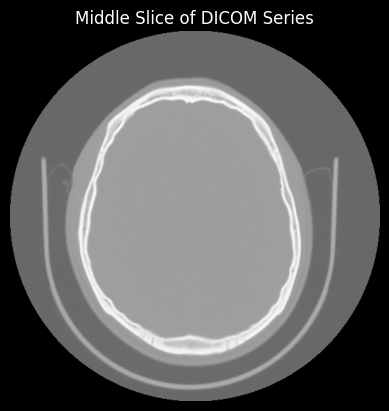

In [24]:
#!/usr/bin/env python

import sys
import os
import SimpleITK as sitk
import matplotlib.pyplot as plt

# !zip -d DICOM.zip .

sys.argv= ["DicomSeriesReader", "imgs/DICOM", "output_image.nii.gz"]  

if len(sys.argv) < 3:
    print("Usage: DicomSeriesReader <input_directory> <output_file>")
    sys.exit(1)

print("Reading Dicom directory:", sys.argv[1])
reader = sitk.ImageSeriesReader()

# Get all series IDs in the directory
series_ids = reader.GetGDCMSeriesIDs(sys.argv[1])
print(f"Found {len(series_ids)} series")
if not series_ids:
    print("No DICOM series found in the given directory.")
    sys.exit(1)
else:
    # Select which series to load (e.g., first one, or change index)
    for i in range(1):
        i=1
        series_index = i  # Change this to load a different series
        series_id = series_ids[series_index]
        print(f"Loading series {series_index}: {series_id}")
        
        # NOW get the file names for this specific series
        dicom_names = reader.GetGDCMSeriesFileNames(sys.argv[1], series_id)
        print(f"Series has {len(dicom_names)} files")
        
        # Load all files in this series
        reader.SetFileNames(dicom_names)
        image = reader.Execute()
        
        size = image.GetSize()
        print(f"Image size: {size[0]} x {size[1]} x {size[2]}")
        
        print(f"Writing image: {sys.argv[2]}")
        sitk.WriteImage(image, sys.argv[2])
        
        # Load and display the image
        image = sitk.ReadImage(sys.argv[2])
        image_array = sitk.GetArrayFromImage(image)
        plt.imshow(image_array[image_array.shape[0]//2, :, :], cmap='gray')
        plt.title('Middle Slice of DICOM Series')
        plt.axis('off')
        plt.show()
        
        # Export to raw
        save_raw(image, "dicom")

In [ ]:
# import the image

img_np = load_raw_numpy(
    "low_low_resolution.raw",
    shape=(100, 128, 128),   # IMPORTANT: SITK uses (z, y, x) order
    dtype=np.int32
)

myshow(sitk.GetImageFromArray(img_np), "Loaded Image")

```
Pau Adell Raventós

SHORT FEEDBACK:
The delivery is in general very well done. Each section has its own explanation, which allows the reader to follow the thread of the work smoothly and understand it at all times.
The visualization examples are great - very clear and really well put together, showing that you've put a lot of effort into them and that you know how to use the tools properly.
However, for some reason, the guidelines for the format conversion part weren't followed. Because of that, even though the rest of the work is excellent, I can't give the highest possible grade.
An improvement on how to crop the images has been left as comment!

Mark: 9.5
```